Some parts of this notebook are adapted from https://github.com/DrKenReid/VAE-for-Molecule-Discovery.git

# A Recommender System for Discovering Chemically Stable Small Molecules✨

This notebook demonstrates how to use a fine-tuned ChemBERTa and a Variational Autoencoder for Molecular Recommendation

If you wish to run this code in Google Colab:
**Click Runtime --> change runtime type --> GPU

## 1. Setting up the env

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from rdkit import Chem
import pandas as pd

In [ ]:
# Load the previouslty fined tuned ChemBERTA model on atomization energy prediction (aka PBE_TZP)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

loaded_model = AutoModelForSequenceClassification.from_pretrained("./output_final")
loaded_tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MTR") # Or load the tokenizer from the saved model

## 2. Data Preparation
Load the QM9 dataset, a standard benchmark in molecular machine learning, which contains approximately 134,000 small organic molecules.

Some molecules in the dataset may have incorrect atom indices. For this demo, we skip these issues, but additional preprocessing can be applied if needed. Here, we use the raw data as is.

In [ ]:
def load_qm9_dataset(url: str = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/qm9.csv") -> pd.DataFrame:
    """
    Download and load the QM9 dataset.

    This function downloads the QM9 dataset from the specified URL using wget,
    then loads it into a pandas DataFrame. It extracts the SMILES strings
    from the DataFrame for further processing.

    Args:
        url (str): The URL of the QM9 dataset CSV file.
                   Defaults to the DeepChem hosted QM9 dataset.

    Returns:
        pd.DataFrame: The loaded QM9 dataset as a pandas DataFrame.

    Raises:
        subprocess.CalledProcessError: If the wget command fails.
        pd.errors.EmptyDataError: If the CSV file is empty or cannot be read.

    Note:
        This function requires wget to be installed and accessible in the system path.
        It saves the downloaded file as 'qm9.csv' in the current directory.
    """
    import subprocess

    # Download the QM9 dataset
    try:
        subprocess.run(['wget', url], check=True)
        print(f"Dataset downloaded successfully from {url}")
    except subprocess.CalledProcessError as e:
        print(f"Failed to download dataset: {e}")
        raise

    # Load the dataset
    try:
        df = pd.read_csv('qm9.csv')
        print(f"Loaded QM9 dataset with {len(df)} entries")
        return df
    except pd.errors.EmptyDataError:
        print("The CSV file is empty or could not be read")
        raise

# go
df = load_qm9_dataset()
smiles_list = df['smiles'].tolist()
print(f"Extracted {len(smiles_list)} SMILES strings from the dataset")

Select a random molecule from the dataset. This molecule will represent a preferred molecule of a user.

In [38]:
import random
random_molecule = random.choice(smiles_list)
# Convert the random SMILES to a canonical form
mol = Chem.MolFromSmiles(random_molecule)
canon_random_molecule =Chem.MolToSmiles(mol)
print(f"Random molecule: {canon_random_molecule}")
print(f"Random molecule (original): {random_molecule}")

Random molecule: N#Cc1ncno1
Random molecule (original): c1nc(on1)C#N


Pedict the atomization energy (AE), also known as PBE_TZP, for the canon_random_molecule. This value will later be used to screen novel molecules that share both a similar structure and a comparable AE value.

In [39]:
inputs = loaded_tokenizer(canon_random_molecule, return_tensors="pt", max_length=512, padding="max_length", truncation=True)

# Move inputs to the correct device
inputs = {k: v.to(loaded_model.device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = loaded_model(**inputs)
    prediction = outputs.logits.item()  # since it's a regression task

print("Predicted value:", prediction)

Predicted value: -36.973628997802734


Creating a Vocabulary: We create a vocabulary from the SMILES strings. This allows us to represent molecules as sequences of tokens that our model can process.

In [6]:
from typing import List, Dict

def create_vocabulary(smiles_list: List[str]) -> Dict[str, int]:
    """
    Create a vocabulary mapping from SMILES characters to integer indices.

    This function generates a vocabulary dictionary from a list of SMILES strings.
    It includes special tokens for start ('<') and end ('>') of sequences, and
    assigns a unique integer index to each unique character found in the SMILES strings.

    Args:
        smiles_list (List[str]): A list of SMILES strings to create the vocabulary from.

    Returns:
        Dict[str, int]: A dictionary mapping characters to their corresponding integer indices.

    Example:
        >>> smiles_list = ['CC(=O)OC1=CC=CC=C1C(=O)O', 'C1=CC=C(C=C1)C(=O)O']
        >>> vocab = create_vocabulary(smiles_list)
        >>> print(vocab)
        {'<': 0, '>': 1, 'C': 2, '(': 3, '=': 4, 'O': 5, ')': 6, '1': 7}

    Note:
        The returned vocabulary will always include '<' and '>' as the first two entries,
        representing start and end tokens respectively.
    """
    vocab = {'<': 0, '>': 1}  # Start and end tokens
    for smiles in smiles_list:
        for char in smiles:
            if char not in vocab:
                vocab[char] = len(vocab)
    return vocab

vocab = create_vocabulary(smiles_list)

## 3. Dataset Creation 
We create a custom dataset that converts **Canonical** SMILES strings into one-hot encoded tensors. This representation allows the model to process the molecular data efficiently.

In [7]:
class SMILESDataset(Dataset):
    """
    A PyTorch Dataset for SMILES strings.
    Canonicalizes SMILES on initialization and converts them into one-hot encoded tensors.    
    It adds start ('<') and end ('>') tokens to each SMILES string before encoding.

    Attributes:
        smiles_list (List[str]): A list of SMILES strings.
        vocab (Dict[str, int]): A dictionary mapping characters to their corresponding indices.
        vocab_size (int): The size of the vocabulary.

    """

    def __init__(self, smiles_list: List[str], vocab: Dict[str, int], max_length: int = 100):
        """
        Initialize the SMILESDataset.

        Args:
            smiles_list (List[str]): A list of SMILES strings to be encoded.
            vocab (Dict[str, int]): A dictionary mapping characters to their corresponding indices.
        """
        self.smiles_list = smiles_list
        self.vocab = vocab
        self.vocab_size = len(vocab)
        self.max_length = max_length
        
        # Canonicalize SMILES
        self.smiles_list = []
        for s in smiles_list:
            mol = Chem.MolFromSmiles(s)
            if mol is not None:
                self.smiles_list.append(Chem.MolToSmiles(mol))  # canonical SMILES


    def __len__(self) -> int:
        """
        Get the number of items in the dataset.

        Returns:
            int: The number of SMILES strings in the dataset.
        """
        return len(self.smiles_list)

    def __getitem__(self, idx: int) -> torch.Tensor:
        """
        Get a one-hot encoded tensor for a SMILES string at the given index.

        Args:
            idx (int): The index of the SMILES string to retrieve.

        Returns:
            torch.Tensor: A one-hot encoded tensor representing the SMILES string.
                          Shape: (len(smiles), vocab_size)

        Note:
            Start ('<') and end ('>') tokens are added to the SMILES string before encoding.
            If a character in the SMILES string is not in the vocabulary, it is encoded as the first token (index 0).
        """

        smiles = '<' + self.smiles_list[idx] + '>'
        encoded = torch.zeros(self.max_length, self.vocab_size)
        for i, c in enumerate(smiles[:self.max_length]):
            encoded[i, self.vocab.get(c, 0)] = 1
        return encoded

## 4. Model Architecture
We use a VAE architecture, which consists of an encoder, a latent space, and a decoder. This architecture is chosen because it can learn a compact representation of the input data and generate new samples from this representation.

In [8]:
class VAE(nn.Module):
    """
    Variational Autoencoder (VAE) for SMILES string generation.

    This VAE encodes SMILES strings into a latent space and decodes latent
    vectors back into SMILES strings. It uses GRU layers for both encoding and decoding.

    Attributes:
        vocab_size (int): Size of the SMILES vocabulary.
        hidden_dim (int): Dimension of the hidden state in GRU layers.
        latent_dim (int): Dimension of the latent space.
        encoder (nn.GRU): GRU layer for encoding input sequences.
        fc_mu (nn.Linear): Fully connected layer for mean of latent space.
        fc_logvar (nn.Linear): Fully connected layer for log variance of latent space.
        decoder (nn.GRU): GRU layer for decoding latent vectors.
        fc_output (nn.Linear): Fully connected layer for output probabilities.
    """

    def __init__(self, vocab_size: int, hidden_dim: int, latent_dim: int):
        """
        Initialize the VAE model.

        Args:
            vocab_size (int): Size of the SMILES vocabulary.
            hidden_dim (int): Dimension of the hidden state in GRU layers.
            latent_dim (int): Dimension of the latent space.
        """
        super(VAE, self).__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        self.encoder = nn.GRU(vocab_size, hidden_dim, batch_first=True)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.GRU(vocab_size + latent_dim, hidden_dim, batch_first=True)
        self.fc_output = nn.Linear(hidden_dim, vocab_size)

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Encode input sequences into the latent space.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, seq_len, vocab_size).

        Returns:
            tuple[torch.Tensor, torch.Tensor]: Mean and log variance of the latent space distribution.
        """
        _, h = self.encoder(x)
        h = h.squeeze(0)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """
        Perform the reparameterization trick to sample from the latent space.

        Args:
            mu (torch.Tensor): Mean of the latent space distribution.
            logvar (torch.Tensor): Log variance of the latent space distribution.

        Returns:
            torch.Tensor: Sampled latent vector.
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor, max_length: int) -> torch.Tensor:
        """
        Decode latent vectors into sequences.

        Args:
            z (torch.Tensor): Latent vector of shape (batch_size, latent_dim).
            max_length (int): Maximum length of the generated sequence.

        Returns:
            torch.Tensor: Decoded sequences of shape (batch_size, max_length, vocab_size).
        """
        batch_size = z.size(0)
        h = torch.zeros(1, batch_size, self.hidden_dim).to(z.device)
        x = torch.zeros(batch_size, 1, self.vocab_size).to(z.device)
        outputs = []

        for _ in range(max_length):
            z_input = z.unsqueeze(1).repeat(1, 1, 1)
            decoder_input = torch.cat([x, z_input], dim=2)
            output, h = self.decoder(decoder_input, h)
            output = self.fc_output(output)
            outputs.append(output)
            x = torch.softmax(output, dim=-1)

        return torch.cat(outputs, dim=1)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Forward pass through the VAE.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, seq_len, vocab_size).

        Returns:
            tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
                - Reconstructed input of shape (batch_size, seq_len, vocab_size)
                - Mean of the latent space distribution
                - Log variance of the latent space distribution
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, x.size(1)), mu, logvar

## 5. Training the Model 
We train the model using a combination of reconstruction loss (binary [cross-entropy](https://en.wikipedia.org/wiki/Cross-entropy)) and [KL divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import os

def loss_function(recon_x: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    BCE = nn.functional.binary_cross_entropy_with_logits(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + 0.1 * KLD

def custom_collate(batch):
    return torch.stack(batch)

# Determine the number of workers based on system resources
num_workers = min(2, os.cpu_count() or 1)

# DataLoader setup
batch_size = 128
dataset = SMILESDataset(smiles_list, vocab, max_length=100)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate,
                        num_workers=num_workers, pin_memory=True)

# Model initialization
vocab_size = len(vocab)
hidden_dim = 256
latent_dim = 64

model = VAE(vocab_size, hidden_dim, latent_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Optimizer initialization
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Initialize mixed precision training if CUDA is available
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# Training loop
num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in dataloader:
        batch = batch.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        # Use autocast only if CUDA is available
        with torch.cuda.amp.autocast(enabled=use_amp):
            recon_batch, mu, logvar = model(batch)
            loss = loss_function(recon_batch, batch, mu, logvar)

        # Backward pass and optimization with gradient scaling if CUDA is available
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    # Print epoch results
    avg_loss = total_loss / len(dataloader.dataset)
    print(f'Epoch {epoch+1}, Average Loss: {avg_loss:.4f}')

    # Update learning rate
    scheduler.step(avg_loss)

    # Print current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Current learning rate: {current_lr:.6f}')

print("Training complete!")

## 6-A. Generate New Molecules near the random_molecule

Prepare the molecules for the VAE model

In [ ]:
random_molecule # original, no canonicalization

'c1nc(on1)C#N'

In [41]:
preferred_smi = SMILESDataset([random_molecule], vocab, max_length=100)
print(f"Preferred SMILES: {preferred_smi[0]}") # torch.Tensor
encoded_preferred_smi = preferred_smi[0].unsqueeze(0).to(device) # add batch dimension, shape (1, max_len, vocab_size)
print(encoded_preferred_smi)
print(f"Encoded preferred SMILES shape: {encoded_preferred_smi.shape}")

Preferred SMILES: tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([[[1., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')
Encoded preferred SMILES shape: torch.Size([1, 100, 23])


Next, we get mu and logvar near the random_molecule:
- mu → the mean vector of the latent Gaussian distribution for this input.
- logvar → the log of the variance vector (log σ²) of the latent Gaussian.

In [ ]:
# Now pass through encoder
mu, logvar = model.encoder(encoded_preferred_smi)
print(f"Encoded preferred SMILES mu: {mu}, logvar: {logvar}")

Next, we sample around the mu and logvar of our encoded SMILES

In [43]:
def generate_smiles(model: torch.nn.Module,
    vocab: Dict[str, int],
    num_samples: int = 10,
    max_length: int = 100,
    mu: torch.Tensor = None,
    logvar: torch.Tensor = None
) -> List[str]:
    """
    Generate SMILES strings using the trained VAE model.

    This function generates a specified number of SMILES strings by sampling from the
    latent space and decoding the samples using the VAE's decoder.

    Args:
        model (torch.nn.Module): The trained VAE model.
        vocab (Dict[str, int]): The vocabulary mapping characters to indices.
        num_samples (int, optional): Number of SMILES strings to generate. Defaults to 10.
        max_length (int, optional): Maximum length of generated SMILES strings. Defaults to 100.

    Returns:
        List[str]: A list of generated SMILES strings.

    Note:
        - The function uses greedy decoding (taking the most probable character at each step).
        - Generation stops when the end token '>' is produced or max_length is reached.
        - Invalid characters (not in vocabulary) are ignored in the output.
    """
    model.eval()  # Set the model to evaluation mode
    inv_vocab = {v: k for k, v in vocab.items()}  # Invert vocabulary for decoding
    generated_smiles = []
    device = next(model.parameters()).device  # Get the device of the model

    with torch.no_grad():  # Disable gradient computation
        for _ in range(num_samples):
            # Sample from the latent space NEAR THE GIVEN ENCODING
            if mu is not None and logvar is not None:
                std = torch.exp(0.5 * logvar)        # convert logvar to std
                z = mu + std * torch.randn_like(std) # sample near the encoded SMILES
            else:
                z = torch.randn(1, model.latent_dim).to(device)
            #z = torch.randn(1, model.latent_dim).to(device) # Sampling randomly from the whole latent space
            x = torch.zeros(1, 1, model.vocab_size).to(device)
            x[0, 0, vocab['<']] = 1  # Start token
            h = torch.zeros(1, 1, model.hidden_dim).to(device)

            smiles = ''
            for _ in range(max_length):
                z_input = z.unsqueeze(1)
                decoder_input = torch.cat([x, z_input], dim=2)
                output, h = model.decoder(decoder_input, h)
                output = model.fc_output(output)

                probs = torch.softmax(output.squeeze(0), dim=-1)
                next_char = torch.multinomial(probs, 1).item()

                if next_char == vocab['>']:  # End token
                    break

                smiles += inv_vocab.get(next_char, '')
                x = torch.zeros(1, 1, model.vocab_size).to(device)
                x[0, 0, next_char] = 1

            generated_smiles.append(smiles)

    return generated_smiles

# Generate and print some SMILES strings
num_samples = 10000
generated_smiles = generate_smiles(model, vocab, num_samples=num_samples)
print(f"Generated {num_samples} SMILES strings:")
for i, smiles in enumerate(generated_smiles, 1):
    print(f"{i}. {smiles}")

Generated 10000 SMILES strings:
1. COCC(2COCO)2ONcC1
2. <C=CCC1CC(C=
3. CH#
4. <CCc1CCC(NCO(12
5. ]-CCCCONCCCC
6. F-3[CNCOCCCCC(C
7. <CC#c=NC1)C)O2C#21
8. <CCC1CN(=)c
9. )NCC=)cN
10. <cC1CONCC11C11C12211
11. 4OCCN2[2C#()NCO
12. [43=5]1C#C=12N[OC)
13. <5-1<c
14. <NcC1CcCC(11C4#C
15. <CC11C)OO2HCC
16. <CC1CNcCC1)C1O(
17. [CN111O(1nC1(33
18. #)#C+#C11C1CC2C1C[C1O
19. <#CO1CCC(C)n
20. <CCCC1=OC[31OO11=
21. <C=C112=[O11=
22. <OCC1Cc(CCCC#OC1)CCN
23. CCCCCC2=COC
24. <CcC(CCCCO(C1N11O
25. #C(CCc)22CcC1CC1C222
26. 54-c[o[5nO)NH22]25[4)51Oc5-OcF]cH[5(H5c]FnN+)5]o2)++F[-N5#5<4]-]oHF
27. +((=C1C([1C223CN1)C11O1C2CCO22O
28. <CCCOCCCCC(CN1#C1o
29. 1oH[32c[-F
30. 2(O]CNCCc1O1)1
31. 4#+NH=1n
32. 3c5C=5FO+-1=35[F
33. 1C1CCC1C1CCO
34. =OCCCCCC(O)22OC312
35. =1=o+5FnOo<532(55=+#4(nn<C+52FFn+<3<+1H5-453F54oH-5H-+F555]+-(3(<4F5n--O54+5H+]5+)F-4#5F534-+F5<FC<4
36. FCCCCC(CC)CC1CCON
37. <CcCCCCCCCCCCCCcC1C11
38. +OO=CCcO]O2=C2C1
39. O-o=](5oFc
40. 11NCOC)[
41. <CC(CC3CCC4N)[=)c
42. =C1C1C1C2C2=O11OCC2N
43. 

## 6-B. Generating New Molecules (randomly from the whole latent space)
After training, we use the decoder to generate new molecular structures.

In [ ]:
def generate_smile_random(model: torch.nn.Module, vocab: Dict[str, int], num_samples: int = 10, max_length: int = 100) -> List[str]:
    """
    Generate SMILES strings using the trained VAE model.

    This function generates a specified number of SMILES strings by sampling from the
    latent space and decoding the samples using the VAE's decoder.

    Args:
        model (torch.nn.Module): The trained VAE model.
        vocab (Dict[str, int]): The vocabulary mapping characters to indices.
        num_samples (int, optional): Number of SMILES strings to generate. Defaults to 10.
        max_length (int, optional): Maximum length of generated SMILES strings. Defaults to 100.

    Returns:
        List[str]: A list of generated SMILES strings.

    Note:
        - The function uses greedy decoding (taking the most probable character at each step).
        - Generation stops when the end token '>' is produced or max_length is reached.
        - Invalid characters (not in vocabulary) are ignored in the output.
    """
    model.eval()  # Set the model to evaluation mode
    inv_vocab = {v: k for k, v in vocab.items()}  # Invert vocabulary for decoding
    generated_smiles = []
    device = next(model.parameters()).device  # Get the device of the model

    with torch.no_grad():  # Disable gradient computation
        for _ in range(num_samples):
            # Sample from the latent space
            z = torch.randn(1, model.latent_dim).to(device)
            x = torch.zeros(1, 1, model.vocab_size).to(device)
            x[0, 0, vocab['<']] = 1  # Start token
            h = torch.zeros(1, 1, model.hidden_dim).to(device)

            smiles = ''
            for _ in range(max_length):
                z_input = z.unsqueeze(1)
                decoder_input = torch.cat([x, z_input], dim=2)
                output, h = model.decoder(decoder_input, h)
                output = model.fc_output(output)

                probs = torch.softmax(output.squeeze(0), dim=-1)
                next_char = torch.multinomial(probs, 1).item()

                if next_char == vocab['>']:  # End token
                    break

                smiles += inv_vocab.get(next_char, '')
                x = torch.zeros(1, 1, model.vocab_size).to(device)
                x[0, 0, next_char] = 1

            generated_smiles.append(smiles)

    return generated_smiles

# Generate and print some SMILES strings
num_samples = 10000
random_generated_smiles = generate_smile_random(model, vocab, num_samples=num_samples)
print(f"Generated {num_samples} SMILES strings:")
for i, smiles in enumerate(random_generated_smiles, 1):
    print(f"{i}. {smiles}")

## 7. Analyzing Generated Molecules 
After generating new molecules, we analyze them for validity, novelty, and potential usefulness. Here are some common analyses and insights we can derive:

### 7.1 Validity Check: First, we'll check how many of our generated SMILES strings represent valid molecules:

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from typing import Tuple, List, Dict

def validate_and_correct_smiles(smiles: str) -> Tuple[bool, str]:
    """
    Validate and attempt to correct a SMILES string.

    Args:
        smiles (str): The SMILES string to validate and correct.

    Returns:
        Tuple[bool, str]: A tuple containing a boolean indicating validity
                          and the corrected SMILES string (or original if invalid).
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        try:
            Chem.SanitizeMol(mol)
            return True, Chem.MolToSmiles(mol, isomericSmiles=True)
        except:
            pass
    return False, smiles

def enhanced_post_process_smiles(smiles: str) -> str:
    """
    Post-process a SMILES string to correct common issues.

    Args:
        smiles (str): The SMILES string to process.

    Returns:
        str: The processed SMILES string.
    """
    smiles = smiles.replace('<', '').replace('>', '')
    allowed_chars = set('CNOPSFIBrClcnops()[]=@+-#0123456789')
    smiles = ''.join(c for c in smiles if c in allowed_chars)

    # Balance parentheses
    open_count = smiles.count('(')
    close_count = smiles.count(')')
    if open_count > close_count:
        smiles += ')' * (open_count - close_count)
    elif close_count > open_count:
        smiles = '(' * (close_count - open_count) + smiles

    # Replace invalid double bonds
    smiles = smiles.replace('==', '=')

    # Attempt to close unclosed rings
    for i in range(1, 10):
        if smiles.count(str(i)) % 2 != 0:
            smiles += str(i)

    return smiles

def analyze_molecules(smiles_list: List[str]) -> Dict:
    """
    Analyze a list of SMILES strings and provide detailed statistics.

    Args:
        smiles_list (List[str]): A list of SMILES strings to analyze.
        loaded_model: The pretrained model for atomization energy prediction.
        loaded_tokenizer: The tokenizer corresponding to the loaded_model.

    Returns:
        Dict: A dictionary containing various statistics and analyses.
    """
    results = {
        'total': len(smiles_list),
        'valid': 0,
        'invalid': 0,
        'unique': 0,
        'corrected': 0,
        'properties': [],
        'invalid_smiles': []
    }
    
    generated_and_valid = []  # <-- List to store valid SMILES
    unique_smiles = set()

    # Ensure model is ready for inference
    loaded_model.eval()
    loaded_model.to("cuda" if torch.cuda.is_available() else "cpu")

    unique_smiles = set()

    for smiles in smiles_list:
        processed_smiles = enhanced_post_process_smiles(smiles)
        is_valid, corrected_smiles = validate_and_correct_smiles(processed_smiles)

        if is_valid:
            results['valid'] += 1
            generated_and_valid.append(corrected_smiles)
            unique_smiles.add(corrected_smiles)
            if corrected_smiles != processed_smiles:
                results['corrected'] += 1

            mol = Chem.MolFromSmiles(corrected_smiles)

            # Tokenize for the model
            inputs = loaded_tokenizer(
                corrected_smiles,
                return_tensors="pt",
                max_length=512,
                padding="max_length",
                truncation=True
            )
            inputs = {k: v.to(loaded_model.device) for k, v in inputs.items()}

            # Predict AE
            with torch.no_grad():
                outputs = loaded_model(**inputs)
                atomization_energy = outputs.logits.item()

            # Append properties
            results['properties'].append({
                'smiles': corrected_smiles,
                'molecular_weight': Descriptors.ExactMolWt(mol),
                'logp': Descriptors.MolLogP(mol),
                'num_atoms': mol.GetNumAtoms(),
                'num_rings': Descriptors.RingCount(mol),
                'atomization_energy': atomization_energy
            })
        else:
            results['invalid'] += 1
            results['invalid_smiles'].append(smiles)

    results['unique'] = len(unique_smiles)
    results['generated_and_valid'] = generated_and_valid 
    return results


# Assume generated_smiles is your list of generated SMILES strings
analysis = analyze_molecules(generated_smiles) # the list of generated SMILES strings near the preferred SMILES

In [45]:
# Save the generated and valid SMILES to a list
generated_and_valid= analysis['generated_and_valid']
print(generated_and_valid)

['CCCCCC1=COC1', 'CCC(CCCCF)CC1CCON1', 'C1CCCCCNCCCC1', 'CCCCCCC1NCCO1', 'CCCCC1COC2OOC12', '', 'CCCC1C2CCC1OOC2', 'CC1=CCCCO1', 'NCC1C#CNCCC=CCN=C1', 'CC1NOC1O', 'CCCCCC1CCCOOC1CC', 'CCCN1CCC2COC21', '', 'CC1CCCCOOCNC1', '', '', '', '', '', '', '', '', 'O', 'NNC1CNC12CN2', 'ON1CCCOC12CC2', 'CCCCC1CONC1CC', 'N', '', 'COC1=C(C)O1', 'CCCCCCCCC1CCO1', 'C1=C2CCC(CC1)OC2', '', '', 'CCCC1=CC=C1N', 'CC12CNCC1=CCOCCC2F', '', '', 'CC1CCCCCNCCC1', 'CC1COC2CCC12', '', '', 'CCCC1=CCONCCC1', '', 'F', 'CCCCCCCOCOCC1CC1', '', '', '', 'N', '', 'CCCC=C1CCNC1', 'FCC1CC2CCON12', 'CC1CCC2CCCC12', '', '', 'CC1C2=CCCCCC21', '', 'CCCOCCC=CCC1CC1C', '', '', 'OC1=COC2NCCC12', 'N', 'CCCCNCOCC', '', '', 'OCCCOC1CCC1', '', '', 'C1CCC1', 'COCCCCCOC#N', 'CCCCCCC', 'CNCC1CCONN1', '', '', 'C#CCCCCC1CCOC1CN', 'NCN1CC12NC1CC12', 'CCCCCOC1CN1', 'CCCCCCOC1CCC(CC)C1', 'N', 'CNCCCCOC1NCOCN1C', 'CCNCCF', '', 'CCCC1CCCCN1C', '', 'CCCCCCCN=C=CN', 'F', 'CCC1COCCCCCO1', '', 'CC', 'CC1=C(CCCCCCF)CN=CCC1', '', 'CC1CCC2CCC12', 'CC

In [46]:
print(analysis['generated_and_valid'])
print(len(analysis['generated_and_valid']))

['CCCCCC1=COC1', 'CCC(CCCCF)CC1CCON1', 'C1CCCCCNCCCC1', 'CCCCCCC1NCCO1', 'CCCCC1COC2OOC12', '', 'CCCC1C2CCC1OOC2', 'CC1=CCCCO1', 'NCC1C#CNCCC=CCN=C1', 'CC1NOC1O', 'CCCCCC1CCCOOC1CC', 'CCCN1CCC2COC21', '', 'CC1CCCCOOCNC1', '', '', '', '', '', '', '', '', 'O', 'NNC1CNC12CN2', 'ON1CCCOC12CC2', 'CCCCC1CONC1CC', 'N', '', 'COC1=C(C)O1', 'CCCCCCCCC1CCO1', 'C1=C2CCC(CC1)OC2', '', '', 'CCCC1=CC=C1N', 'CC12CNCC1=CCOCCC2F', '', '', 'CC1CCCCCNCCC1', 'CC1COC2CCC12', '', '', 'CCCC1=CCONCCC1', '', 'F', 'CCCCCCCOCOCC1CC1', '', '', '', 'N', '', 'CCCC=C1CCNC1', 'FCC1CC2CCON12', 'CC1CCC2CCCC12', '', '', 'CC1C2=CCCCCC21', '', 'CCCOCCC=CCC1CC1C', '', '', 'OC1=COC2NCCC12', 'N', 'CCCCNCOCC', '', '', 'OCCCOC1CCC1', '', '', 'C1CCC1', 'COCCCCCOC#N', 'CCCCCCC', 'CNCC1CCONN1', '', '', 'C#CCCCCC1CCOC1CN', 'NCN1CC12NC1CC12', 'CCCCCOC1CN1', 'CCCCCCOC1CCC(CC)C1', 'N', 'CNCCCCOC1NCOCN1C', 'CCNCCF', '', 'CCCC1CCCCN1C', '', 'CCCCCCCN=C=CN', 'F', 'CCC1COCCCCCO1', '', 'CC', 'CC1=C(CCCCCCF)CN=CCC1', '', 'CC1CCC2CCC12', 'CC

In [47]:
# Print summary
print(f"Total SMILES: {analysis['total']}")
print(f"Valid SMILES: {analysis['valid']} ({analysis['valid']/analysis['total']:.2%})") # <--These are the smiles saved in the csv file below
print(f"Invalid SMILES: {analysis['invalid']} ({analysis['invalid']/analysis['total']:.2%})")
print(f"Unique SMILES: {analysis['unique']} ({analysis['unique']/analysis['total']:.2%})")
print(f"Corrected SMILES: {analysis['corrected']} ({analysis['corrected']/analysis['total']:.2%})")

# Print property statistics
df = pd.DataFrame(analysis['properties'])
print("\nProperty Statistics:")
print(df.describe())

# Print some invalid SMILES
print("\nSample of Invalid SMILES:")
for smiles in analysis['invalid_smiles'][:5]:  # Print first 5 invalid SMILES
    print(smiles)

# Optionally, save the full analysis to a CSV file
df.to_csv('molecule_properties.csv', index=False)
print("\nFull property analysis saved to 'molecule_properties.csv'")

Total SMILES: 10000
Valid SMILES: 620 (6.20%)
Invalid SMILES: 9380 (93.80%)
Unique SMILES: 334 (3.34%)
Corrected SMILES: 270 (2.70%)

Property Statistics:
       molecular_weight        logp   num_atoms   num_rings  \
count        620.000000  620.000000  620.000000  620.000000   
mean          77.694785    0.794094    5.456452    0.643548   
std           75.634467    1.239024    5.338286    0.810098   
min            0.000000   -2.279000    0.000000    0.000000   
25%            0.000000    0.000000    0.000000    0.000000   
50%           82.575875    0.000000    6.000000    0.000000   
75%          146.106819    1.573325   10.000000    1.000000   
max          256.215078    5.069900   18.000000    3.000000   

       atomization_energy  
count          620.000000  
mean           -40.469433  
std              9.230978  
min            -68.261230  
25%            -46.671392  
50%            -36.390797  
75%            -36.390797  
max            -21.513371  

Sample of Invalid SMILES

In [ ]:
print(len(analysis))
analysis

In [49]:
print(analysis['valid'])

620


### 7.2 Novelty Assessment We can check if our generated molecules are novel (not present in the training set)

memo: the function does not check for validity of the novel_molecules

In [50]:
from typing import List, Set

def check_novelty(generated_smiles: List[str], training_smiles: Set[str]) -> tuple[List[str], float]:
    """
    Check the novelty of generated SMILES strings against a training set.

    This function determines which of the generated SMILES strings are not present
    in the training set, and calculates the novelty rate.

    Args:
        generated_smiles (List[str]): A list of SMILES strings generated by the model.
        training_smiles (Set[str]): A set of SMILES strings used for training the model.

    Returns:
        tuple[List[str], float]: A tuple containing:
            - A list of novel SMILES strings (those not in the training set).
            - The novelty rate as a float (proportion of novel SMILES).

    Example:
        >>> training_set = {"CC", "CCO", "CCCC"}
        >>> generated_smiles = ["CC", "CCC", "CCCO", "CCO"]
        >>> novel, rate = check_novelty(generated_smiles, training_set)
        >>> print(novel)
        ['CCC', 'CCCO']
        >>> print(f"Novelty rate: {rate:.2%}")
        Novelty rate: 50.00%
    """
    novel_molecules = [s for s in generated_smiles if s not in training_smiles]
    novelty_rate = len(novel_molecules) / len(generated_smiles)
    return novel_molecules, novelty_rate

training_set = set(smiles_list)  # Convert training list to a set for faster lookup
novel_molecules, novelty_rate = check_novelty(generated_and_valid, training_set)

print(f"Novelty rate: {novelty_rate:.2%}")
print(f"Number of novel molecules: {len(novel_molecules)}")
print("\nSample of novel molecules:")
for smiles in novel_molecules[:5]:  # Print first 5 novel SMILES
    print(smiles)

Novelty rate: 89.03%
Number of novel molecules: 552

Sample of novel molecules:
CCCCCC1=COC1
CCC(CCCCF)CC1CCON1
C1CCCCCNCCCC1
CCCCCCC1NCCO1
CCCCC1COC2OOC12


### 7.3 Property Calculation: Calculate some basic molecular properties and AE for novel molecules:

In [51]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from typing import List, Dict, Optional
import torch

def calculate_properties(smiles: str) -> Optional[Dict[str, float]]:
    """
    Calculate molecular properties for a given SMILES string, including predicted atomization energy (AE).
    Uses globally loaded_model and loaded_tokenizer.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # RDKit properties
    props = {
        'MolWt': Descriptors.ExactMolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol)
    }

    # AE prediction using global model
    inputs = loaded_tokenizer(smiles, return_tensors="pt", max_length=512,
                              padding="max_length", truncation=True)
    inputs = {k: v.to(loaded_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = loaded_model(**inputs)
        props['AtomizationEnergy'] = outputs.logits.item()

    return props


def analyze_molecules(generated_smiles: List[str]) -> Dict[str, any]:
    """
    Analyze generated molecules for validity, uniqueness, and calculate properties.
    """
    total = len(generated_smiles)
    valid_smiles = []
    invalid_smiles = []
    corrected_count = 0  # placeholder if you have SMILES correction logic

    seen = set()
    for s in generated_smiles:
        if Chem.MolFromSmiles(s):
            valid_smiles.append(s)
            seen.add(s)
        else:
            invalid_smiles.append(s)

    unique_count = len(seen)

    # Calculate properties for valid SMILES
    properties = [calculate_properties(s) for s in valid_smiles]

    return {
        'total': total,
        'valid': len(valid_smiles),
        'invalid': len(invalid_smiles),
        'unique': unique_count,
        'corrected': corrected_count,
        'invalid_smiles': invalid_smiles,
        'properties': [p for p in properties if p is not None]
    }


def print_analysis_summary(analysis: Dict[str, any], csv_path: Optional[str] = None):
    """
    Print a formatted summary of analysis results and optionally save property statistics to CSV.
    """
    # Summary counts
    print(f"Total SMILES: {analysis['total']}")
    print(f"Valid SMILES: {analysis['valid']} ({analysis['valid']/analysis['total']:.2%})")
    print(f"Invalid SMILES: {analysis['invalid']} ({analysis['invalid']/analysis['total']:.2%})")
    print(f"Unique SMILES: {analysis['unique']} ({analysis['unique']/analysis['total']:.2%})")
    print(f"Corrected SMILES: {analysis['corrected']} ({analysis['corrected']/analysis['total']:.2%})")

    # Property statistics
    if analysis['properties']:
        df = pd.DataFrame(analysis['properties'])
        # Sort by AtomizationEnergy in ascending order
        df = df.sort_values(by='AtomizationEnergy', ascending=True)
        print("\nProperty Statistics:")
        print(df.describe())

        # Save CSV if path provided
        if csv_path:
            df.to_csv(csv_path, index=False)
            print(f"\nProperties saved to: {csv_path}")

    # Sample invalid SMILES
    if analysis['invalid_smiles']:
        print("\nSample of Invalid SMILES:")
        for smiles in analysis['invalid_smiles'][:5]:
            print(smiles)


In [52]:
valid_novel_mols_properties = analyze_molecules(novel_molecules)
print_analysis_summary(valid_novel_mols_properties, csv_path="novel_molecule_properties.csv")


Total SMILES: 552
Valid SMILES: 552 (100.00%)
Invalid SMILES: 0 (0.00%)
Unique SMILES: 299 (54.17%)
Corrected SMILES: 0 (0.00%)

Property Statistics:
            MolWt        LogP  NumHDonors  NumHAcceptors  AtomizationEnergy
count  552.000000  552.000000  552.000000     552.000000         552.000000
mean    79.716626    0.779062    0.521739       1.117754         -41.729382
std     78.321073    1.234741    0.805763       1.403487           8.627707
min      0.000000   -2.279000    0.000000       0.000000         -68.261230
25%      0.000000    0.000000    0.000000       0.000000         -47.678214
50%     86.594599    0.000000    0.000000       1.000000         -36.390797
75%    154.108476    1.527625    1.000000       2.000000         -36.390797
max    256.215078    5.069900    4.000000       6.000000         -21.513371

Properties saved to: novel_molecule_properties.csv


### 7.4 Visualizing Generated Molecules: We can visualize some of the valid novel generated molecules

In [53]:
novel_molecules

['CCCCCC1=COC1',
 'CCC(CCCCF)CC1CCON1',
 'C1CCCCCNCCCC1',
 'CCCCCCC1NCCO1',
 'CCCCC1COC2OOC12',
 '',
 'CCCC1C2CCC1OOC2',
 'CC1=CCCCO1',
 'NCC1C#CNCCC=CCN=C1',
 'CC1NOC1O',
 'CCCCCC1CCCOOC1CC',
 'CCCN1CCC2COC21',
 '',
 'CC1CCCCOOCNC1',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 'NNC1CNC12CN2',
 'ON1CCCOC12CC2',
 'CCCCC1CONC1CC',
 '',
 'COC1=C(C)O1',
 'CCCCCCCCC1CCO1',
 'C1=C2CCC(CC1)OC2',
 '',
 '',
 'CCCC1=CC=C1N',
 'CC12CNCC1=CCOCCC2F',
 '',
 '',
 'CC1CCCCCNCCC1',
 '',
 '',
 'CCCC1=CCONCCC1',
 '',
 'F',
 'CCCCCCCOCOCC1CC1',
 '',
 '',
 '',
 '',
 'CCCC=C1CCNC1',
 'FCC1CC2CCON12',
 '',
 '',
 'CC1C2=CCCCCC21',
 '',
 'CCCOCCC=CCC1CC1C',
 '',
 '',
 'OC1=COC2NCCC12',
 'CCCCNCOCC',
 '',
 '',
 'OCCCOC1CCC1',
 '',
 '',
 'COCCCCCOC#N',
 'CNCC1CCONN1',
 '',
 '',
 'C#CCCCCC1CCOC1CN',
 'NCN1CC12NC1CC12',
 'CCCCCOC1CN1',
 'CCCCCCOC1CCC(CC)C1',
 'CNCCCCOC1NCOCN1C',
 'CCNCCF',
 '',
 'CCCC1CCCCN1C',
 '',
 'CCCCCCCN=C=CN',
 'F',
 'CCC1COCCCCCO1',
 '',
 'CC1=C(CCCCCCF)CN=CCC1',
 '',
 'CCCCC1CCCCCCCC1',
 '',

In [54]:
# REmove the empty strings from the list
novel_molecules = [s for s in novel_molecules if s.strip()]
novel_molecules

['CCCCCC1=COC1',
 'CCC(CCCCF)CC1CCON1',
 'C1CCCCCNCCCC1',
 'CCCCCCC1NCCO1',
 'CCCCC1COC2OOC12',
 'CCCC1C2CCC1OOC2',
 'CC1=CCCCO1',
 'NCC1C#CNCCC=CCN=C1',
 'CC1NOC1O',
 'CCCCCC1CCCOOC1CC',
 'CCCN1CCC2COC21',
 'CC1CCCCOOCNC1',
 'NNC1CNC12CN2',
 'ON1CCCOC12CC2',
 'CCCCC1CONC1CC',
 'COC1=C(C)O1',
 'CCCCCCCCC1CCO1',
 'C1=C2CCC(CC1)OC2',
 'CCCC1=CC=C1N',
 'CC12CNCC1=CCOCCC2F',
 'CC1CCCCCNCCC1',
 'CCCC1=CCONCCC1',
 'F',
 'CCCCCCCOCOCC1CC1',
 'CCCC=C1CCNC1',
 'FCC1CC2CCON12',
 'CC1C2=CCCCCC21',
 'CCCOCCC=CCC1CC1C',
 'OC1=COC2NCCC12',
 'CCCCNCOCC',
 'OCCCOC1CCC1',
 'COCCCCCOC#N',
 'CNCC1CCONN1',
 'C#CCCCCC1CCOC1CN',
 'NCN1CC12NC1CC12',
 'CCCCCOC1CN1',
 'CCCCCCOC1CCC(CC)C1',
 'CNCCCCOC1NCOCN1C',
 'CCNCCF',
 'CCCC1CCCCN1C',
 'CCCCCCCN=C=CN',
 'F',
 'CCC1COCCCCCO1',
 'CC1=C(CCCCCCF)CN=CCC1',
 'CCCCC1CCCCCCCC1',
 'F',
 'NC12NC1CCCO2',
 'CCCCCN',
 'CCC1CCCC2COCCC12',
 'C1CCNC2OCC2CC1',
 'CNC1CCC=CCCOC1',
 'CC1CCCCCCC1CN',
 'O=C1CC12CCC2',
 'NCC=CCOCC12NC1NCOO2',
 'CC1CCC2CCN3CCC123',
 'CCCNC1CCCCCC1

/home/elisa/miniconda3/envs/recom_sys_qm9_new/lib/python3.13/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(
INFO:__main__:Generated molecule images saved as 'generated_molecules.png'


0 molecules not drawn due to invalidity. Drawing 306 molecules...
Visualization of generated molecules successful. Image saved as: generated_molecules.png


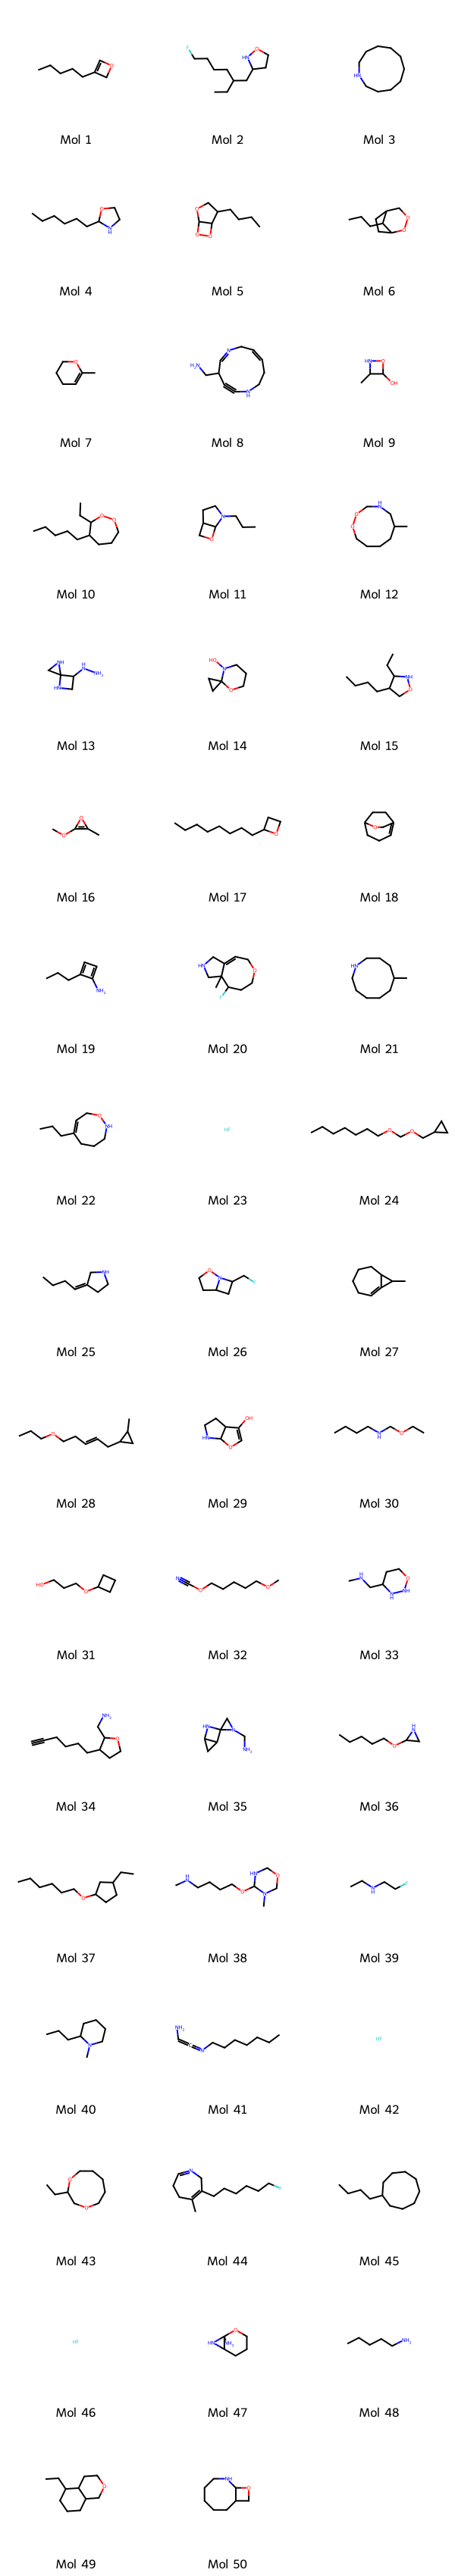

In [55]:
from rdkit import Chem
from rdkit.Chem import Draw
from typing import List, Optional, Tuple
import logging
from PIL import Image
import io
from IPython.display import display

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def visualize_molecules(smiles_list: List[str], n: int = 5, filename: str = "generated_molecules.png") -> Optional[Tuple[str, Image.Image]]:
    """
    Visualize a list of generated molecules from their SMILES strings, save and return the image.

    This function takes the list of generated SMILES strings, converts them to RDKit molecule objects,
    generates a grid image of the molecules, and both saves and returns the image.

    Args:
        smiles_list (List[str]): The list of generated SMILES strings to visualize.
        n (int, optional): Maximum number of molecules to visualize. Defaults to 5.
        filename (str, optional): Name of the file to save the image. Defaults to "generated_molecules.png".

    Returns:
        Optional[Tuple[str, Image.Image]]: A tuple containing the filename of the saved image and the Image object if successful, None otherwise.

    Raises:
        ValueError: If no valid molecules are found in the input list.
    """
    valid_mols = []
    invalid_count = 0
    for i, smiles in enumerate(smiles_list):
        # Remove any start/end tokens and whitespace
        smiles = smiles.strip().strip('<>').strip()
        if not smiles:  # Skip empty strings
            invalid_count += 1
            continue
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                valid_mols.append(mol)
                # if len(valid_mols) == n:
                #     break
            else:
                logger.warning(f"Invalid SMILES at index {i}: {smiles}")
                invalid_count += 1
        except Exception as e:
            logger.error(f"Error processing SMILES at index {i}: {smiles}. Error: {str(e)}")
            invalid_count += 1

    if not valid_mols:
        logger.error("No valid molecules found in the generated SMILES list.")
        return None

    print(f"{invalid_count} molecules not drawn due to invalidity. Drawing {len(valid_mols)} molecules...")

    try:
        img = Draw.MolsToGridImage(
            valid_mols,
            molsPerRow=min(3, len(valid_mols)),
            subImgSize=(200, 200),
            legends=[f"Mol {i+1}" for i in range(len(valid_mols))]
        )
        # Convert the RDKit image to a PIL Image
        img_pil = Image.open(io.BytesIO(img.data))
        img_pil.save(filename)
        logger.info(f"Generated molecule images saved as '{filename}'")
        return filename, img_pil
    except Exception as e:
        logger.error(f"Error saving generated molecule image: {str(e)}")
        return None

# The function call and display code
result = visualize_molecules(novel_molecules)

if result:
    filename, img = result
    print(f"Visualization of generated molecules successful. Image saved as: {filename}")
    display(img)
else:
    print("Visualization of generated molecules failed.")